In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# ── Shared parameters ────────────────────────────────────────────────────────
V_list = [9, 12, 15]
K_MAP = {9: 200, 12: 500, 15: 2000}          # V -> k in the numerical file name
dE = 0.50

# (a)/(b)/(c) sweep: maximally-chaotic point
H1_ABC, H2_ABC, BETA_ABC = 0.35, 1.10, 0.00

# (d): h1 = h2 = 1, three beta values
H1_D, H2_D = 1.00, 1.00
BETA_D_LIST = [0.00, 0.06, 0.12]

COLORS = {9: "tab:blue", 12: "tab:orange", 15: "tab:green"}
BETA_COLORS = {0.00: "tab:blue", 0.06: "tab:orange", 0.12: "tab:green"}

LABEL_FONTSIZE = 14
TITLE_FONTSIZE = 14
TICK_FONTSIZE  = 14
LEGEND_FONTSIZE = 12

In [3]:
BASE_DIR = Path(".")

def numerical_filename(V, h1, h2, beta):
    """Path to the numerical sweep file for a given V, h1, h2, beta (VC = V//3 fixed)."""
    VC = V // 3
    k = K_MAP[V]
    return (
        BASE_DIR / "numerical"
        / f"multi_entropy_fixed_VC_V_{V}_h1_{h1:.2f}_h2_{h2:.2f}"
          f"_beta_{beta:.2f}_k_{k}_dE_{dE:.2f}_VC_{VC}.csv"
    )


def analytical_filename(V, beta):
    """Path to the analytical file for a given V, beta (NC = V//3 fixed)."""
    VC = V // 3
    return BASE_DIR / "analytical" / f"N_{V}_NC_{VC}_beta_{beta:.2f}_multi_analytical_LG.csv"


def load_numerical(V, h1, h2, beta):
    return pd.read_csv(numerical_filename(V, h1, h2, beta))


def load_analytical(V, beta):
    return pd.read_csv(analytical_filename(V, beta), header=None, names=["V_B", "V_C", "value"])

In [4]:
# ── Leading-order formulas (V_C = V/3 fixed) ─────────────────────────────────
def leading_order_a(fB, fC=1/3):
    """S_2^(3)/(V ln2) leading order: 1 - max(f_A, f_B, f_C)."""
    fA = 1 - fC - fB
    return 1 - max(fA, fB, fC)


def leading_order_b(fB, fC=1/3):
    """GM_2^(3)/(V ln2) leading order."""
    fA = 1 - fC - fB
    if fA > 0.5 or fB > 0.5:
        return 0.0
    if fB < fA:
        return 0.5 * (fB + fC - fA)
    else:
        return 0.5 * (fA + fC - fB)

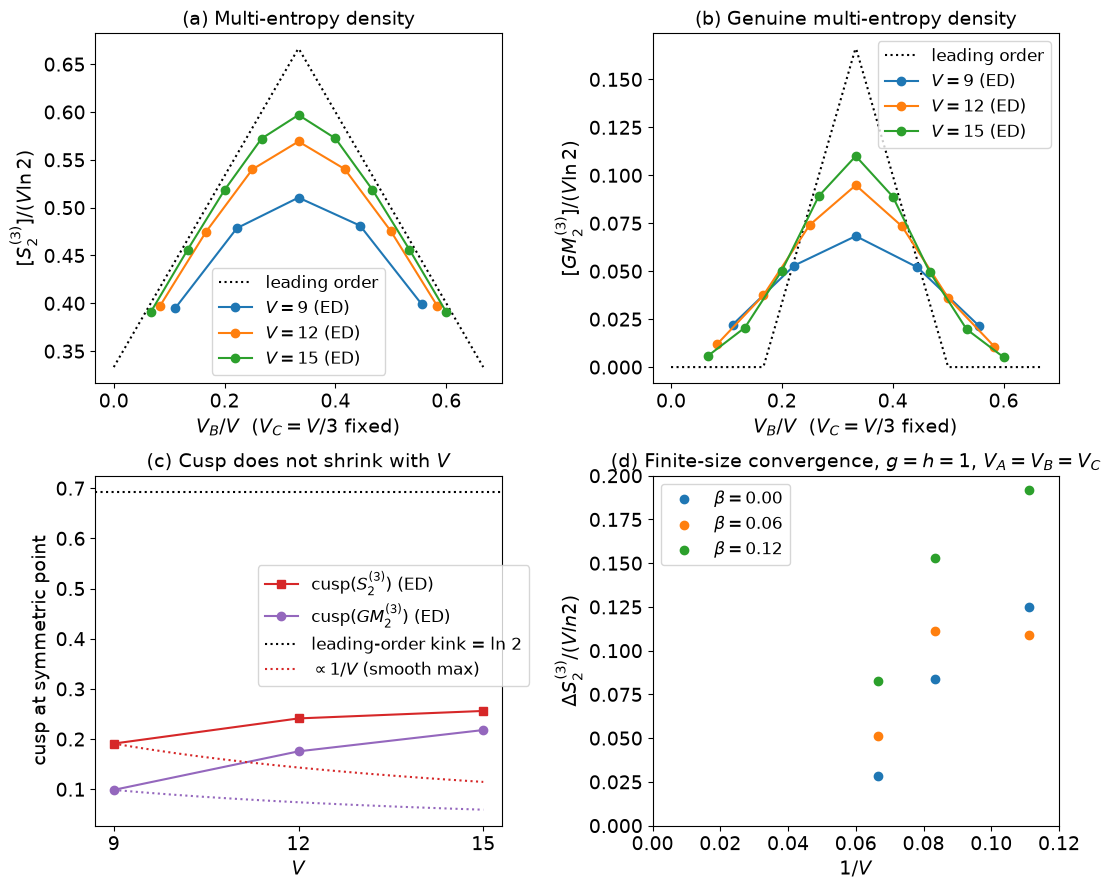

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
ax_a, ax_b = axes[0]
ax_c, ax_d = axes[1]

# ── Panel (a): multi-entropy density ────────────────────────────────────────
fB_grid = np.linspace(0, 2/3, 400)
leading_a_curve = [leading_order_a(fB) for fB in fB_grid]
ax_a.plot(fB_grid, leading_a_curve, "k:", label="leading order")

for V in V_list:
    df = load_numerical(V, H1_ABC, H2_ABC, BETA_ABC)
    x = df["N_B"] / V
    y = df["multi_entropy_avg"] / V
    ax_a.plot(x, y, "o-", color=COLORS[V], label=f"$V={V}$ (ED)")

ax_a.set_title("(a) Multi-entropy density", fontsize=TITLE_FONTSIZE)
ax_a.set_xlabel(r"$V_B/V$  ($V_C = V/3$ fixed)", fontsize=LABEL_FONTSIZE)
ax_a.set_ylabel(r"$[S_2^{(3)}]/(V\ln 2)$", fontsize=LABEL_FONTSIZE)
ax_a.tick_params(axis="both", labelsize=TICK_FONTSIZE)
ax_a.legend(fontsize=LEGEND_FONTSIZE)

# ── Panel (b): genuine multi-entropy density ────────────────────────────────
leading_b_curve = [leading_order_b(fB) for fB in fB_grid]
ax_b.plot(fB_grid, leading_b_curve, "k:", label="leading order")

for V in V_list:
    df = load_numerical(V, H1_ABC, H2_ABC, BETA_ABC)
    x = df["N_B"] / V
    y = df["kappa_avg"] / V
    ax_b.plot(x, y, "o-", color=COLORS[V], label=f"$V={V}$ (ED)")

ax_b.set_title("(b) Genuine multi-entropy density", fontsize=TITLE_FONTSIZE)
ax_b.set_xlabel(r"$V_B/V$  ($V_C = V/3$ fixed)", fontsize=LABEL_FONTSIZE)
ax_b.set_ylabel(r"$[GM_2^{(3)}]/(V\ln 2)$", fontsize=LABEL_FONTSIZE)
ax_b.tick_params(axis="both", labelsize=TICK_FONTSIZE)
ax_b.legend(fontsize=LEGEND_FONTSIZE)

# ── Panel (c): cusp does not shrink with V ──────────────────────────────────
def cusp_at_symmetric_point(V, value_col):
    """cusp = f(N_B=V/3) - 1/2 [f(N_B=V/3+1) + f(N_B=V/3-1)],  f = value_col/V."""
    df = load_numerical(V, H1_ABC, H2_ABC, BETA_ABC)
    df = df.set_index("N_B")
    VC = V // 3
    f_center = df.loc[VC, value_col] * np.log(2)
    f_plus   = df.loc[VC + 1, value_col] * np.log(2)
    f_minus  = df.loc[VC - 1, value_col] * np.log(2)
    return f_center - 0.5 * (f_plus + f_minus)


cusp_S  = np.array([cusp_at_symmetric_point(V, "multi_entropy_avg") for V in V_list])
cusp_GM = np.array([cusp_at_symmetric_point(V, "kappa_avg")         for V in V_list])

ax_c.plot(V_list, cusp_S,  "s-", color="tab:red",    label=r"cusp($S_2^{(3)}$) (ED)")
ax_c.plot(V_list, cusp_GM, "o-", color="tab:purple", label=r"cusp($GM_2^{(3)}$) (ED)")

ax_c.axhline(y=np.log(2), color="black", linestyle=":", label="leading-order kink = ln 2")

# ∝1/V trend lines, each calibrated from its own V=9 value
V_smooth = np.linspace(min(V_list), max(V_list), 200)
alpha_S  = cusp_S[0]  * V_list[0]
alpha_GM = cusp_GM[0] * V_list[0]
ax_c.plot(V_smooth, alpha_S / V_smooth,  ":", color="tab:red",    label=r"$\propto 1/V$ (smooth max)")
ax_c.plot(V_smooth, alpha_GM / V_smooth, ":", color="tab:purple")

ax_c.set_title("(c) Cusp does not shrink with $V$", fontsize=TITLE_FONTSIZE)
ax_c.set_xlabel(r"$V$", fontsize=LABEL_FONTSIZE)
ax_c.set_ylabel("cusp at symmetric point", fontsize=LABEL_FONTSIZE)
ax_c.set_xticks(V_list)
ax_c.tick_params(axis="both", labelsize=TICK_FONTSIZE)
ax_c.legend(fontsize=LEGEND_FONTSIZE, loc=(0.4, 0.4))


# ── Panel (d): finite-size convergence ──────────────────────────────────────
for beta in BETA_D_LIST:
    diffs = []
    inv_V = []
    for V in V_list:
        VC = V // 3

        df_num = load_numerical(V, H1_D, H2_D, beta).set_index("N_B")
        numeric_val = df_num.loc[VC, "multi_entropy_avg"]

        df_ana = load_analytical(V, beta)
        row = df_ana[(df_ana["V_B"] == VC) & (df_ana["V_C"] == VC)]
        analytic_val = row["value"].iloc[0]

        diffs.append(abs(numeric_val - analytic_val) / V)
        inv_V.append(1 / V)

    ax_d.scatter(inv_V, diffs, color=BETA_COLORS[beta], label=fr"$\beta = {beta:.2f}$")

ax_d.set_title(r"(d) Finite-size convergence, $g=h=1$, $V_A=V_B=V_C$", fontsize=TITLE_FONTSIZE)
ax_d.set_xlabel(r"$1/V$", fontsize=LABEL_FONTSIZE)
ax_d.set_ylabel(r"$\Delta S_2^{(3)}/(V ln2)$", fontsize=LABEL_FONTSIZE)
ax_d.tick_params(axis="both", labelsize=TICK_FONTSIZE)
ax_d.set_xlim(0, 0.12)
ax_d.set_ylim(0, 0.2)
ax_d.legend(fontsize=LEGEND_FONTSIZE)

fig.tight_layout()
fig.savefig(BASE_DIR / "fig_4.pdf", dpi=300, bbox_inches="tight")
plt.show()